In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

In [6]:
df=pd.read_csv("../ai4i2020.csv")

In [7]:
print(df.shape)

(10000, 14)


In [8]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [9]:
df.tail()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0
9999,10000,M24859,M,299.0,308.7,1500,40.2,30,0,0,0,0,0,0


In [10]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

FINDING THE NO OF MACHINE FAILURE

In [11]:
df["Machine failure"].value_counts() 

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [12]:
df["Type"].value_counts()

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

In [13]:
df[["UDI","Product ID","Type"]].head(10)

,UDI,Product ID,Type
0,1,M14860,M
1,2,L47181,L
2,3,L47182,L
3,4,L47183,L
4,5,L47184,L
5,6,M14865,M
6,7,L47186,L
7,8,L47187,L
8,9,M14868,M
9,10,M14869,M


In [14]:
df[["Air temperature [K]","Rotational speed [rpm]","Torque [Nm]","Tool wear [min]"]].describe()

,Air temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,300.004930,1538.776100,39.986910,107.951000
std,2.000259,179.284096,9.968934,63.654147
min,295.300000,1168.000000,3.800000,0.000000
25%,298.300000,1423.000000,33.200000,53.000000
50%,300.100000,1503.000000,40.100000,108.000000
75%,301.500000,1612.000000,46.800000,162.000000
max,304.500000,2886.000000,76.600000,253.000000


In [15]:
df[["TWF","HDF","PWF","OSF","RNF"]].sum()


TWF     46
HDF    115
PWF     95
OSF     98
RNF     19
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [23]:
features=["Air temperature [K]","Process temperature [K]","Rotational speed [rpm]","Torque [Nm]","Tool wear [min]"]
df[features].agg(["min","max"])

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
min,295.3,305.7,1168,3.8,0
max,304.5,313.8,2886,76.6,253


In [26]:
print("Type",df["Type"].unique())
binary_cols=["Machine failure","TWF","HDF","PWF","OSF","RNF"]
for col in binary_cols:
    print(col,":",df[col].unique())

Type ['M' 'L' 'H']
Machine failure : [0 1]
TWF : [0 1]
HDF : [0 1]
PWF : [0 1]
OSF : [0 1]
RNF : [0 1]


In [36]:
df["Type"].nunique()

3

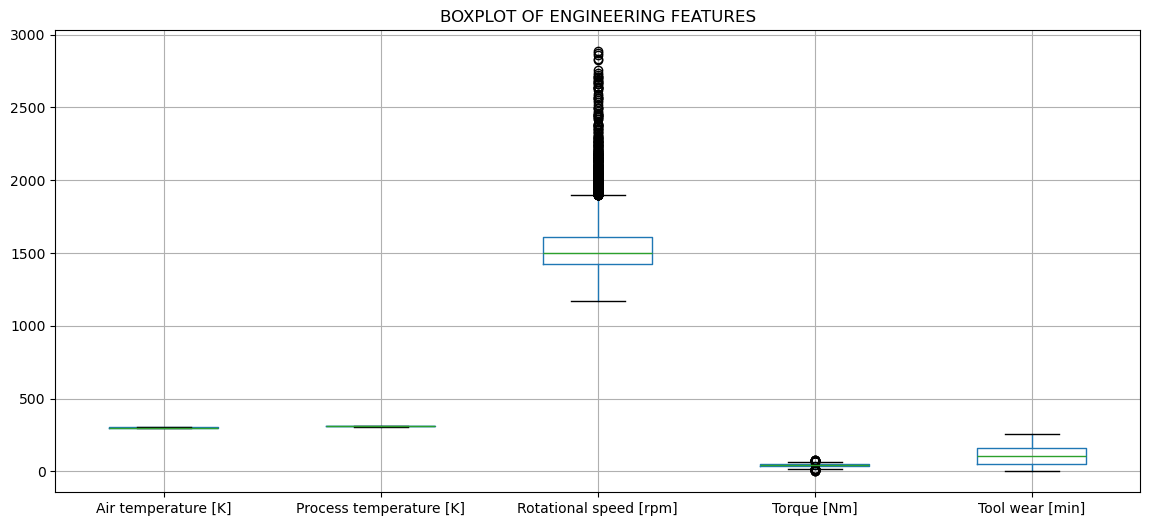

In [43]:
df[features].boxplot(figsize=(14,6))
plt.xticks(rotation=0)
plt.title("BOXPLOT OF ENGINEERING FEATURES")
plt.show()

In [47]:
MAXX=df["Rotational speed [rpm]"].max()
MINN=df["Rotational speed [rpm]"].min()
Q1=df["Rotational speed [rpm]"].quantile(0.25)
Q3=df["Rotational speed [rpm]"].quantile(0.75)
IQR=Q3-Q1
l_b=Q1-1.5*IQR
u_b=Q3+1.5*IQR
print("MIN",MINN)
print("LOWER BOUND",l_b)
print("25 percentile",Q1)
print("IQR",IQR)
print("75 percentile",Q3)
print("UPPER BOUND",u_b)
print("MAX",MAXX)


MIN 1168
LOWER BOUND 1139.5
25 percentile 1423.0
IQR 189.0
75 percentile 1612.0
UPPER BOUND 1895.5
MAX 2886


In [52]:
outliers=df[df["Rotational speed [rpm]"]>u_b]
print(len(outliers))

418


In [53]:
outliers["Machine failure"].value_counts()

Machine failure
0    383
1     35
Name: count, dtype: int64

In [54]:
df

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


In [56]:
failure_cols=["TWF","HDF","PWF","OSF","RNF"]
for col in failure_cols:
    print("\n",col)
    print(pd.crosstab(df[col],df["Machine failure"]))


 TWF
Machine failure     0    1
TWF                       
0                9661  293
1                   0   46

 HDF
Machine failure     0    1
HDF                       
0                9661  224
1                   0  115

 PWF
Machine failure     0    1
PWF                       
0                9661  244
1                   0   95

 OSF
Machine failure     0    1
OSF                       
0                9661  241
1                   0   98

 RNF
Machine failure     0    1
RNF                       
0                9643  338
1                  18    1


In [57]:
for col in failure_cols:
    print(col,"FAILURE CASES",df.loc[df[col]==1,"Machine failure"].sum(),"/",df[col].sum())


TWF FAILURE CASES 46 / 46
HDF FAILURE CASES 115 / 115
PWF FAILURE CASES 95 / 95
OSF FAILURE CASES 98 / 98
RNF FAILURE CASES 1 / 19


In [58]:
print(np.isinf(df.select_dtypes(include=np.number)).sum())

UDI                        0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


numpy.number